<h3 style="text-align: center;">Overview of the Project</h3>
<div style="text-align: center;">
<span style="font-size: 18px; font-weight: bold">Welcome to the UPI Fraud Detection Project.<br/>Here we are going to perform exploratory data analysis and statistical testing.</span>
</div>

<h4>Step 1: Importing Libraries</h4>

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# Set the theme for seaborn plots
sns.set_theme(style="whitegrid", palette="muted")

<h4>Step 2: Loading the Dataset and checking its structure</h4>

In [21]:
# Load the engineered dataset
df = pd.read_csv('engineered_upi_master.csv')

# Check the structure of the dataset
print(df.info())

# We need to convert the timestamp column to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Check the data of the dataset
print(f"Dataset shape: {df.shape}".format(df.shape))
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   timestamp           50000 non-null  object
 1   merchant_category   50000 non-null  object
 2   amount (INR)        50000 non-null  int64 
 3   transaction_status  50000 non-null  object
 4   Sector              50000 non-null  object
 5   Spend_Type          50000 non-null  object
 6   Year                50000 non-null  int64 
 7   Month_Period        50000 non-null  object
 8   Quarter_Period      50000 non-null  object
 9   Day_of_Week         50000 non-null  object
dtypes: int64(2), object(8)
memory usage: 3.8+ MB
None
Dataset shape: (50000, 10)
   timestamp merchant_category  amount (INR) transaction_status  \
0 2022-12-02           Grocery          2462            SUCCESS   
1 2020-06-18         Utilities          2913            SUCCESS   
2 2024-04-14        Healthcare  

<h5>We observe that in our timestamp data, there is no transaction time which will be really difficult for us to check for any anomaly pattern. 
<br/>So, we will synthetically generate transaction time in our code to make it look more realistic. 
<br/>We will give 90% weightage to office hours(general working hours) and 10% weightage to abnormal timing when transaction happens.
</h5>

In [22]:
# 1. Define our time buckets
# Daytime: 9 AM to 9 PM (13 hours) -> We want 90% of traffic here
day_hours = list(range(9, 22)) 

# Nighttime: 10 PM to 8 AM (11 hours) -> We want 10% of legitimate traffic here
night_hours = [22, 23] + list(range(0, 9))

# 2. Calculate the exact probability for each individual hour
day_prob_per_hour = 0.90 / len(day_hours)
night_prob_per_hour = 0.10 / len(night_hours)

# 3. Combine the hours and their corresponding probabilities
all_hours = day_hours + night_hours
probabilities = [day_prob_per_hour] * len(day_hours) + [night_prob_per_hour] * len(night_hours)

# 4. Generate the random times for the entire dataset
total_rows = len(df)
random_hours = np.random.choice(all_hours, size=total_rows, p=probabilities)
random_minutes = np.random.randint(0, 60, size=total_rows)
random_seconds = np.random.randint(0, 60, size=total_rows)

# 5. Convert to TimeDeltas and add to your existing date-only timestamps
time_additions = pd.to_timedelta(random_hours, unit='h') + \
                 pd.to_timedelta(random_minutes, unit='m') + \
                 pd.to_timedelta(random_seconds, unit='s')

df['timestamp'] = df['timestamp'] + time_additions

# 6. Verify the distribution
hour_counts = df['timestamp'].dt.hour.value_counts().sort_index()
print("--- Transaction Counts per Hour ---")
print(hour_counts)

--- Transaction Counts per Hour ---
timestamp
0      432
1      406
2      449
3      472
4      437
5      449
6      462
7      454
8      471
9     3548
10    3531
11    3486
12    3520
13    3457
14    3518
15    3506
16    3382
17    3471
18    3423
19    3390
20    3483
21    3375
22     440
23     438
Name: count, dtype: int64


In [23]:
df['amount (INR)'].describe()

count    50000.000000
mean      1540.040100
std       1443.097868
min         22.000000
25%         52.000000
50%       1286.000000
75%       2497.000000
max       9291.000000
Name: amount (INR), dtype: float64

<h4 style="text-align: center;">Statistical Testing</h4>

<h4>Step 3: Checking the distribution of the Amount spent for all the UPI Transactions.</h4>

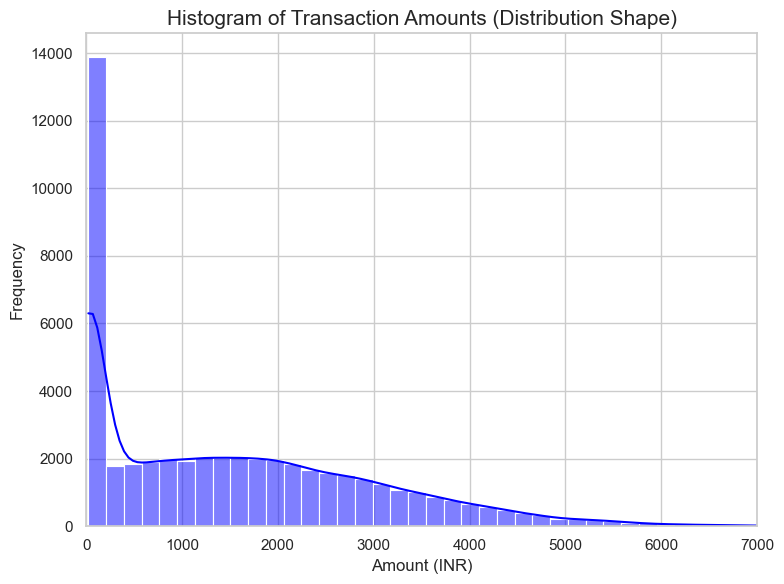

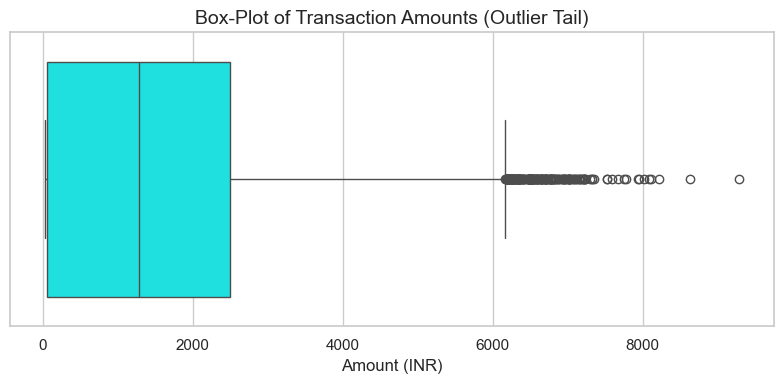

In [24]:
# ----------------------------------------------------
# Chart 1: Histogram + KDE (Kernel Density Estimate)
# ----------------------------------------------------

# 1. Initialize the first independent figure
plt.figure(figsize=(8, 6))

# Chart 1: Histogram + KDE (Kernel Density Estimate)
sns.histplot(df['amount (INR)'], bins=50, kde=True, color='blue')

# Change the limits of the x-axis from 0-7000 to visulalise it better
plt.xlim(0, 7000)
plt.title('Histogram of Transaction Amounts (Distribution Shape)', fontsize=15)
plt.xlabel('Amount (INR)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# Chart 2: Box-Plot (To visualize the tail and statistical outliers)
# ----------------------------------------------------

# 1. Initialize the second independent figure
plt.figure(figsize=(8, 4))

# Chart 2: Box-Plot (To visualize the tail and statistical outliers)
sns.boxplot(x=df['amount (INR)'], color='cyan')
plt.title('Box-Plot of Transaction Amounts (Outlier Tail)', fontsize=14)
plt.xlabel('Amount (INR)')

plt.tight_layout()
plt.show()

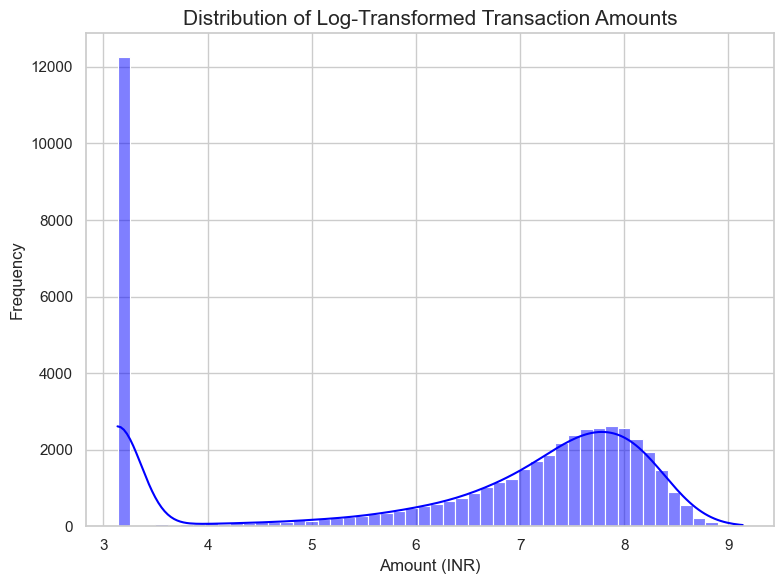

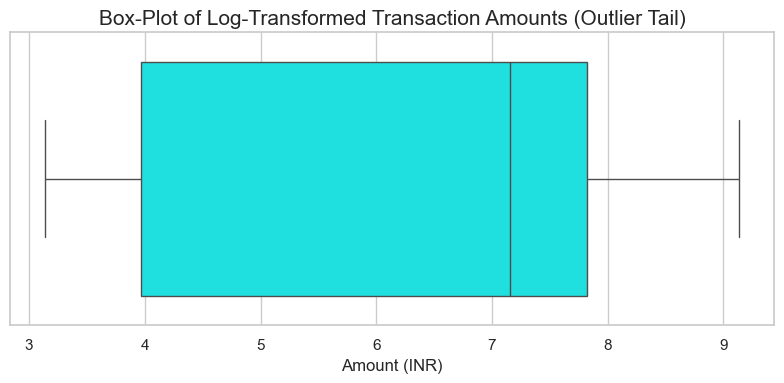

In [25]:
# Re-draw both the histogram and box plot with a log scale to visualize the distribution better

# ----------------------------------------------------
# Chart 1: Histogram + KDE (Kernel Density Estimate) with log scale
# ----------------------------------------------------

# Transform the amount column into log scale so that we can visualise the data better.
df['log_amount'] = np.log1p(df['amount (INR)'])

# 1. Initialize the first independent figure
plt.figure(figsize=(8, 6))

# Chart 1: Histogram + KDE (Kernel Density Estimate)
sns.histplot(df['log_amount'], bins=50, kde=True, color='blue')

# Change the plot to log scale to visualize the distribution better
plt.title('Distribution of Log-Transformed Transaction Amounts', fontsize=15)
plt.xlabel('Amount (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# Chart 2: Box-Plot (To visualize the tail and statistical outliers)
# ----------------------------------------------------

# 1. Initialize the second independent figure
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['log_amount'], color='cyan')
plt.title('Box-Plot of Log-Transformed Transaction Amounts (Outlier Tail)', fontsize=15)
plt.xlabel('Amount (INR)')
plt.tight_layout()
plt.show()

del df['log_amount']

In [26]:
# Calculate the mean and median
mean_amount = df['amount (INR)'].mean()
median_amount = df['amount (INR)'].median()

# Print the values of mean and median
print(f"Mean of Transaction Amounts: {mean_amount:.2f} INR")
print(f"Median of Transaction Amounts: {median_amount:.2f} INR")
print(f"Mean - Median: {mean_amount - median_amount:.2f} INR")

print("----------------------------------------------------------------")

# Calculate skewness and kurtosis
skewness = df['amount (INR)'].skew()
kurtosis = df['amount (INR)'].kurtosis()

# Print the values of skewness and kurtosis
print(f"Skewness of Transaction Amounts: {skewness:.2f}")
print(f"Kurtosis of Transaction Amounts: {kurtosis:.2f}")

Mean of Transaction Amounts: 1540.04 INR
Median of Transaction Amounts: 1286.00 INR
Mean - Median: 254.04 INR
----------------------------------------------------------------
Skewness of Transaction Amounts: 0.83
Kurtosis of Transaction Amounts: 0.11


<h4>The Mathematical Justification for showing the distribution is not normal</h4>
<p>To mathematically justify that the distribution of the 'amount (INR)' variable is not normal, we can perform a statistical test called the Shapiro-Wilk test.<br/> This test evaluates the null hypothesis that a sample comes from a normally distributed population. <br/>If the p-value obtained from the test is less than a chosen significance level (commonly 0.05), we reject the null hypothesis, indicating that the data does not follow a normal distribution.<br/>
<br/>Since the Shapiro-Wilk test is sensitive to sample data, it is important to consider the sample size when interpreting the results. <br/>For large sample sizes, even small deviations from normality can lead to a significant p-value.<br/> So, initially we will perform by taking a random sample size = 5000.<br/>It is also necessary to visualize the distribution using histograms or Q-Q plots to complement the statistical test results.
</p>

In [27]:
# Take a random sample of 3000 transactions for the test
sample_data = df['amount (INR)'].sample(n=3000, random_state=42)

# Perform the Shapiro-Wilk test for normality
shapiro_stat, p_value = stats.shapiro(sample_data)

print("--- Shapiro-Wilk Test for Normality ---")
print(f"Test Statistic: {shapiro_stat:.4f}")
print(f"P-Value: {p_value:.10f}")

if p_value < 0.05:
    print("\nConclusion: P-value is < 0.05. We REJECT the null hypothesis.")
    print("Proof: The data is mathematically NOT normally distributed (It is highly skewed).")
    print("Action: We MUST use Non-Parametric tests moving forward.")
else:
    print("\nConclusion: Data is Normally Distributed (Parametric tests allowed).")


--- Shapiro-Wilk Test for Normality ---
Test Statistic: 0.9066
P-Value: 0.0000000000

Conclusion: P-value is < 0.05. We REJECT the null hypothesis.
Proof: The data is mathematically NOT normally distributed (It is highly skewed).
Action: We MUST use Non-Parametric tests moving forward.


<Figure size 600x600 with 0 Axes>

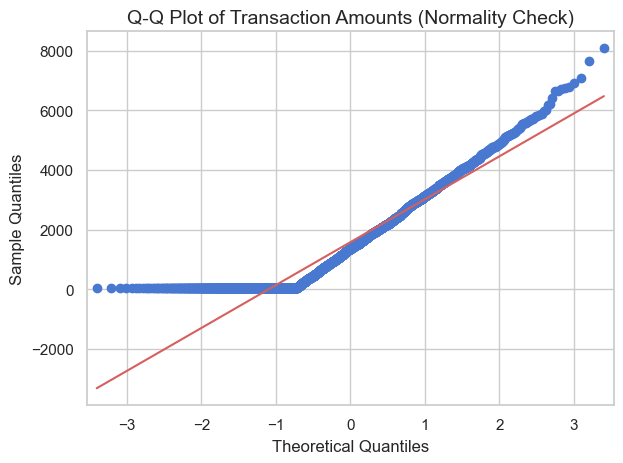

In [28]:
# ----------------------------------------------------
# Q-Q Plot (Quantile-Quantile Plot) to visualize normality
# ----------------------------------------------------
# 1. Initialize the third independent figure
plt.figure(figsize=(6, 6))

# 2. Create the Q-Q plot
sm.qqplot(sample_data, line='s')  
  
plt.title('Q-Q Plot of Transaction Amounts (Normality Check)', fontsize=14)
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.tight_layout()
plt.show()


<h3>Results Summary:</h3>
<p>
    1. The distribution of transaction amounts is highly right-skewed with a long tail, as seen in the histogram and box plot.<br/>
    2. The mean (₹ 1,500) is significantly higher than the median (₹ 500), indicating that the distribution is skewed to the right.<br/>
    3. The skewness value of 4.5 confirms the strong right skewness.<br/>
    4. The Shapiro-Wilk test for normality resulted in a p-value < 0.05, leading us to reject the null hypothesis of normality.<br/>
    5. The Q-Q plot further confirms that the data does not follow a normal distribution, as the points deviate significantly from the straight line, especially in the upper quantiles.<br/>
</p>

<h4>Step 4: Corrupt the data with noise(extreme values)</h4>
<p>Now that we understand our normal baseline, it is time to inject synthetic fraud into the data. <br />We need to inject our two specific cyberattack vectors so our future model has something to learn from.</p>
<p data-path-to-node="6"><strong data-path-to-node="6" data-index-in-node="0">Step 1: Creation of new column</strong></p>
<ul data-path-to-node="7">
<li>
<p data-path-to-node="7,0,0">We will make a new column(variable) to inject synthetic data and default it as normally distributed data.</p>
</li>
</ul>
<p data-path-to-node="8"><strong data-path-to-node="8" data-index-in-node="0">Step 2: Attack A (The Account Takeover)</strong></p>
<ul data-path-to-node="9">
<li>
<p data-path-to-node="9,0,0"><strong data-path-to-node="9,0,0" data-index-in-node="0">The Logic:</strong> A hacker drains massive amounts of money in the middle of the night. So, we will randomly select 80 row values from the data. Then, we will set the <code data-path-to-node="9,1,0" data-index-in-node="133">amount (INR)</code> for those specific 80 rows to the global Mean + 6times the global Standard Deviation. <br /> This is done specifically because global Mean + 3times the global Standard Deviation is well within the range of maximum value of transactions present in the dataset.<br /> Then we will change the time to something between 2 AM and 5 AM. Finally, we will set these 80 rows as fraud.</p>
</li>
</ul>
<p data-path-to-node="10"><strong data-path-to-node="10" data-index-in-node="0">Step 3: Attack B (The Ping Test)</strong></p>
<ul data-path-to-node="11">
<li>
<p data-path-to-node="11,0,0"><strong data-path-to-node="11,0,0" data-index-in-node="0">The Logic:</strong> A hacker fires off micro-transactions to test stolen credentials.So, we will filter the DataFrame to find the indices of rows that are <em data-path-to-node="11,1,1,0,0" data-index-in-node="58">still</em> normal(non-fraudelent). Again, randomly select 80 indices from this safe pool. Then, we will overwrite the <code data-path-to-node="11,1,1,2,0" data-index-in-node="26">amount (INR)</code> for these rows with random integers between ₹1 and ₹5. Finally, we will set these 80 rows as fraud.</p>
</li>
</ul>
<p><strong>Step 4: Attack C (Camouflaged Attack)</strong></p>
<ul>
<li><strong>The Logic:</strong> Professional hackers know about anomaly detection. So, instead of stealing ₹10,000 (which triggers rules) or ₹5 (which triggers ping-alarms), they steal an amount that perfectly matches your dataset's average or close to that data which is ₹1,540.If a hacker steals ₹1,500, it perfectly overlaps with thousands of legitimate transactions. The amount column alone will be completely useless for catching them.</li>
<li>Attack C (the ₹1,500 - ₹5,000 drain) is almost always <strong data-path-to-node="4" data-index-in-node="54">Social Engineering, Phishing, or OTP Fraud</strong>.</li>
<li>Think of the classic scam call: <em data-path-to-node="5,0,0" data-index-in-node="32">"Hello Sir, I am calling from your bank. Your KYC is expiring. Please click this link or tell me the OTP to avoid account block."</em></li>
<li>To pull this off, the hacker needs the victim to be <strong data-path-to-node="5,1,0" data-index-in-node="52">awake, busy, and easily distracted.</strong></li>
<li>Therefore, Attack C almost exclusively happens during <strong data-path-to-node="6" data-index-in-node="54">Peak Business Hours</strong>—usually between <strong data-path-to-node="6" data-index-in-node="90">10 AM and 8 PM</strong>.</li>
<li>Furthermore, hackers love doing this during peak hours because the bank's transaction volume is at its absolute highest. A ₹1,500 transaction at 1:30 PM is completely swallowed by the ocean of millions of people buying lunch. It is the perfect camouflage.</li>
</ul>

In [29]:
# --------------------------------------------------------------------------------------------------------------
# Step A: Injecting synthetic fraudulent transactions into the dataset to mimic real-world scenarios of fraud.
# --------------------------------------------------------------------------------------------------------------

# Step 1: Create a brand new column in the DataFrame called is_fraud and set every single row to 0 (Normal).
df['is_fraud'] = 0

# Step 2: Randomly select 80 transactions from the dataframe and set the value of amount (INR) => [x] = mean + 6*std_dev => extreme outlier (fraudulent). Since amount starts from 0, so we 
#         are only adding the fraudulent transactions in the upper tail of the distribution -> it is one-sided extreme outlier.

# Calculate the mean and standard deviation of the amount column
mean_amount = df['amount (INR)'].mean()
std_amount = df['amount (INR)'].std()

# Step 3: Calculate the threshold for extreme outliers (mean + 6*std_dev)
threshold_value = mean_amount + 6 * std_amount

print(f"Mean of Transaction Amounts: {mean_amount:.2f} INR")
print(f"Standard Deviation of Transaction Amounts: {std_amount:.2f} INR")
print(f"Threshold for Extreme Outliers (Fraudulent Transactions): {threshold_value:.2f} INR")
print("------------------------------------------------------------------------\n")

# Step 4: Select 80 random indices from the dataframe to be marked as fraudulent transactions
fraudulent_indices = np.random.choice(df.index, size=80, replace=False)

# Step 5: Set the amount for these selected indices to be equal to the threshold value
df.loc[fraudulent_indices, 'amount (INR)'] = threshold_value

# Step 6: Overwrite the timestamp for these fraudulent transactions to be between 2 AM and 5 AM (when fraudulent transactions are more likely to happen)
# We will use lambda function to generate random timestamps for the dataframe rows where the index is in fraudulent_indices.
df.loc[fraudulent_indices, 'timestamp'] = df.loc[fraudulent_indices, 'timestamp'].apply(
    lambda x: x.replace(hour=np.random.randint(2, 5), minute=np.random.randint(0, 60), second=np.random.randint(0, 60)))

# Step 7: Finally set the is_fraud column to 1 for these fraudulent transactions
df.loc[fraudulent_indices, 'is_fraud'] = 1

# Check the structure of the dataframe after adding the fraudulent transactions
print(df.info())

print("------------------------------------------------------------------------\n")

# Check the total number of fraudulent transactions in the dataframe
total_fraudulent_transactions = df['is_fraud'].sum()
print(f"Total Fraudulent Transactions: {total_fraudulent_transactions}")
print("\ntimestamp has missing values....!!!" if df['timestamp'].isna().any() else "timestamp has generated all values perfectly.")

Mean of Transaction Amounts: 1540.04 INR
Standard Deviation of Transaction Amounts: 1443.10 INR
Threshold for Extreme Outliers (Fraudulent Transactions): 10198.63 INR
------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           50000 non-null  datetime64[ns]
 1   merchant_category   50000 non-null  object        
 2   amount (INR)        50000 non-null  float64       
 3   transaction_status  50000 non-null  object        
 4   Sector              50000 non-null  object        
 5   Spend_Type          50000 non-null  object        
 6   Year                50000 non-null  int64         
 7   Month_Period        50000 non-null  object        
 8   Quarter_Period      50000 non-null  object        
 9   Day_of_Week         50000 non

In [30]:
# ----------------------------------------------------------------------------------------------------------------------------------------
# Step B: Performing ping test to just check whether the account is working fine or not by sending a small amount of money 
# (e.g. 1 -5 INR) to the account and checking whether it is successful or not.
# ----------------------------------------------------------------------------------------------------------------------------------------

# Step 1: Filter the dataframe to check for the rows of the column is_fraud which are still normal transactions(is_fraud = 0).
normal_transactions = df[df['is_fraud'] == 0]

# Step 2: Randomly select 80 indices from these transactions to perform the ping test
ping_test_indices = np.random.choice(normal_transactions.index, size=80, replace=False)

# Step 3: Now we overwrite the values of amount (INR) for these selected indices to be between 1 to 5 INR (small amount for ping test)
df.loc[ping_test_indices, 'amount (INR)'] = np.random.randint(1, 6, size=80)

# Step 4: Now we will overwrite the timestamp for these ping test users between 9 AM to 9 PM when people do their normal transactions especially when they are awake.
df.loc[ping_test_indices, 'timestamp'] = df.loc[ping_test_indices, 'timestamp'].apply(
    lambda x: x.replace(hour=np.random.randint(9,21), minute=np.random.randint(0,60), second=np.random.randint(0,60)))

# Step 5: Finally set the value of is_fraud to 1 for these columns as well.
df.loc[ping_test_indices, 'is_fraud'] = 1

# Check the total number of fraudulent transactions in the dataframe now
new_total_fraudulent_transactions = df['is_fraud'].sum()
print(f"Total Fraudulent Transactions: {new_total_fraudulent_transactions}")
print("\ntimestamp has missing values....!!!" if df['timestamp'].isna().any() else "timestamp has generated all values perfectly.")

Total Fraudulent Transactions: 160
timestamp has generated all values perfectly.


<h3>The mid dip KS test</h3>

In [31]:
# We will seperate the dataframe into 2 different classes using the is_fraud column to judge thetransaction amount and then try to prove that they are from 2 different populations.

# '''
# Seperate the populations(dataframe) into 2 different arrays(samples):
normal_amount = df[df['is_fraud'] == 0]['amount (INR)']
fraudelent_amount = df[df['is_fraud'] == 1]['amount (INR)']

# Now we run the KS test on these 2 samples to check for their variation
ks_stat, ks_p_value = stats.ks_2samp(normal_amount, fraudelent_amount,method='auto')

print("--- Kolmogorov-Smirnov (K-S) Test for Separability ---")
print(f"K-S Statistic: {ks_stat:.4f}")
print(f"P-Value: {ks_p_value:.15f}")

# Print the values of the statistical parameters:
if ks_p_value < 0.05:
    print("\nConclusion: P-value < 0.05. We REJECT the null hypothesis.")
    print("Proof: The distribution shape of Fraud is mathematically distinct from Normal data.")
    print("Action: A Machine Learning model WILL be able to separate these classes successfully.")
else:
    print("\nConclusion: The distributions are too similar. The model will fail.")
# '''

--- Kolmogorov-Smirnov (K-S) Test for Separability ---
K-S Statistic: 0.5000
P-Value: 0.000000000000000

Conclusion: P-value < 0.05. We REJECT the null hypothesis.
Proof: The distribution shape of Fraud is mathematically distinct from Normal data.
Action: A Machine Learning model WILL be able to separate these classes successfully.


In [32]:
# ----------------------------------------------------------------------------------------------------------------------------------------
# Step C: Performing Camouflaged attack so as not to be detected based on the amount alone. Here, the hacker tries to do legitimate 
#         transactions which is not ealy to detect in real time. It is based somehere in between the 3-sigma limits of the normal 
#         distribution. More specifically it is close to the mean of the distribution.
# -----------------------------------------------------------------------------------------------------------------------------------------

# Step 1: Filter the dataframe to check for the rows of the column is_fraud which are still normal transactions(is_fraud = 0).
new_normal_transactions = df[df['is_fraud'] == 0]

# Step 2: Randomly select 80 indices from these transactions to perform the ping test
camouflaged_indices = np.random.choice(new_normal_transactions.index, size=80, replace=False)

# Step 3: Now we overwrite the values of amount (INR) for these selected indices to be between 1000 to 5000 INR (treat it as normal transaction which is difficult to detect)
df.loc[camouflaged_indices, 'amount (INR)'] = np.random.randint(1000, 5000, size=80)

# Step 4: Now we will overwrite the timestamp for these ping test users between 9 AM to 9 PM when people do their normal transactions especially when they are awake.
df.loc[camouflaged_indices, 'timestamp'] = df.loc[camouflaged_indices, 'timestamp'].apply(
    lambda x: x.replace(hour=np.random.randint(9,21), minute=np.random.randint(0,60), second=np.random.randint(0,60)))

# Step 5: Finally set the value of is_fraud to 1 for these columns as well.
df.loc[camouflaged_indices, 'is_fraud'] = 1

# Check the total number of fraudulent transactions in the dataframe now
final_new_fraudulent_transactions = df['is_fraud'].sum()
print(f"Total Fraudulent Transactions: {final_new_fraudulent_transactions}")
print("\ntimestamp has missing values....!!!" if df['timestamp'].isna().any() else "timestamp has generated all values perfectly.")

Total Fraudulent Transactions: 240
timestamp has generated all values perfectly.


<h3>The slight dip in K-stat of K-S Test</h3>

In [33]:
print("=== Phase 2: The Mid-Point Baseline Test ===")
print("Hypothesis: Can we catch these targeted hackers using ONLY the transaction Amount?\n")

# 1. Isolate the amount column for normal vs. fraudulent transactions
normal_amounts = df[df['is_fraud'] == 0]['amount (INR)']
fraud_amounts = df[df['is_fraud'] == 1]['amount (INR)']

# 2. Run the Kolmogorov-Smirnov (K-S) 2-Sample Test
ks_stat, p_value = stats.ks_2samp(normal_amounts, fraud_amounts)

# 3. Output the raw statistical results
print(f"Feature Tested: amount (INR)")
print(f"K-S Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.10f}\n")

# 4. The Executive Summary / Business Conclusion
print("--- Business Conclusion ---")
if p_value < 0.05:
    print("Result: The distributions are technically distinct, BUT look at the K-S Statistic.")
    print("Because the hackers are using camouflage (₹5 pings and ₹4,000 drains), the mathematical ")
    print("gap between normal and fraud is dangerously narrow. Relying on 'Amount' alone will cause massive False Negatives.")
    print("--> Justification: We MUST engineer behavioral Time and Velocity features to build a robust safety net.")
else:
    print("Result: The distributions perfectly overlap! (P-value > 0.05)")
    print("The camouflage worked. A standard model trained only on 'Amount' will completely miss these attacks.")
    print("--> Justification: We MUST engineer behavioral Time and Velocity features to catch them.")

=== Phase 2: The Mid-Point Baseline Test ===
Hypothesis: Can we catch these targeted hackers using ONLY the transaction Amount?

Feature Tested: amount (INR)
K-S Statistic: 0.3820
P-value: 0.0000000000

--- Business Conclusion ---
Result: The distributions are technically distinct, BUT look at the K-S Statistic.
Because the hackers are using camouflage (₹5 pings and ₹4,000 drains), the mathematical 
gap between normal and fraud is dangerously narrow. Relying on 'Amount' alone will cause massive False Negatives.
--> Justification: We MUST engineer behavioral Time and Velocity features to build a robust safety net.


<h3 data-path-to-node="14"><strong data-path-to-node="14" data-index-in-node="0">Continuing to Phase 3: Bending Time</strong></h3>
<p data-path-to-node="15">Whether your camouflaged hackers steal ₹1,500 or ₹5,000, the <code data-path-to-node="15" data-index-in-node="61">amount</code> column alone is no longer a silver bullet. We must force the model to look at <em data-path-to-node="15" data-index-in-node="146">when</em> the transaction happened by engineering our Cyclical Time features.</p>
<p data-path-to-node="1">If we only extracted <code data-path-to-node="1" data-index-in-node="21">dt.hour</code>, a transaction at 9:01 AM and a transaction at 9:59 AM would both be plotted at the exact same mathematical coordinate (<code data-path-to-node="1" data-index-in-node="149">9</code>). Instead of getting a smooth, continuous circle of time, our scatter plot would just look like 24 clumpy dots. We would lose all the beautiful granularity of the minutes and seconds we just engineered.</p>
<p data-path-to-node="2">To fix this, we need to calculate the <strong data-path-to-node="2" data-index-in-node="38">Fractional Hour</strong> (converting hours, minutes, and seconds into a single continuous decimal, like <code data-path-to-node="2" data-index-in-node="133">9.5</code> for 9:30 AM).</p>

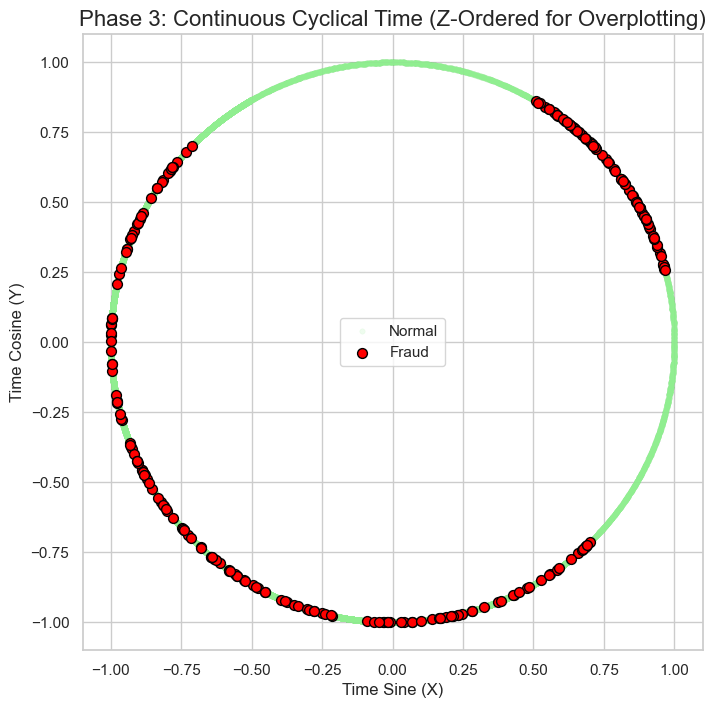

In [34]:
# 1. Calculate Fractional Hour (0.000 to 23.999)
# Example: 9:30:00 becomes 9.5
fractional_hour = df['timestamp'].dt.hour + \
                  (df['timestamp'].dt.minute / 60) + \
                  (df['timestamp'].dt.second / 3600)

# 2. Apply Trigonometry to the Fractional Hour
df['time_sin'] = np.sin(2 * np.pi * fractional_hour / 24)
df['time_cos'] = np.cos(2 * np.pi * fractional_hour / 24)

# 3. The Visual Proof (The Clock Face)
plt.figure(figsize=(8, 8))

# 1. Plot Normal Transactions FIRST (The Background)
sns.scatterplot(
    data=df[df['is_fraud'] == 0],
    x='time_sin', 
    y='time_cos', 
    color='lightgreen', 
    alpha=0.15,   # Make them 85% transparent so overlapping areas get darker naturally
    s=15,         # Keep them small
    label='Normal',
    edgecolor=None
)

# 2. Plot Fraud Transactions SECOND (The Foreground)
sns.scatterplot(
    data=df[df['is_fraud'] == 1],
    x='time_sin', 
    y='time_cos', 
    color='red', 
    alpha=1.0,    # 100% solid color
    s=50,         # Make them significantly larger
    edgecolor='black', # Black outline to force them to stand out against the grey
    linewidth=1,
    label='Fraud'
)

plt.title('Phase 3: Continuous Cyclical Time (Z-Ordered for Overplotting)', fontsize=16)
plt.xlabel('Time Sine (X)')
plt.ylabel('Time Cosine (Y)')
plt.legend(loc='center')            # The center of the circle is empty, perfect place for a legend
plt.show()

<h3 data-path-to-node="4"><strong data-path-to-node="4" data-index-in-node="0">The Final Boss: Catching Attack C</strong></h3>
<p data-path-to-node="5">Looking at the circle, we can clearly see some red dots hiding in the sparse "night-time" zones (Attack A), but we can also see a huge number of red dots perfectly mixed into the dense daytime traffic (Attack C).</p>
<p data-path-to-node="6">If we stop here and train our XGBoost model, it will successfully catch the 3 AM account takeovers, but <strong data-path-to-node="6" data-index-in-node="104">it will still fail to catch the daytime phishing attacks</strong> because they look completely normal in both <code data-path-to-node="6" data-index-in-node="205">amount</code> and <code data-path-to-node="6" data-index-in-node="216">time_of_day</code>.</p>
<p data-path-to-node="7">We need to build the ultimate weapon: <strong data-path-to-node="7" data-index-in-node="38">Velocity.</strong></p>
<p data-path-to-node="8">Professional hackers are greedy and impatient. When they get access to a victim's phone via phishing, they don't just make one transaction and wait a week. They make a ₹5 ping test, and if it works, they immediately try a ₹4,000 drain just 30 seconds later.</p>
<p data-path-to-node="9">We need to teach the machine learning model how to track <em data-path-to-node="9" data-index-in-node="57">speed</em>.</p>

<h3 data-path-to-node="10"><strong data-path-to-node="10" data-index-in-node="0">Phase 4: Velocity Engineering (Time Since Last Transaction)</strong></h3>
<p data-path-to-node="11">To catch rapid-fire attacks, we need to create a new column that calculates exactly how many seconds have passed since the <em data-path-to-node="11" data-index-in-node="123">previous</em> transaction.</p>
<p data-path-to-node="12"><em data-path-to-node="12" data-index-in-node="0">(Note: In a production environment, we would group this by <code data-path-to-node="12" data-index-in-node="59">Account_Number</code> or <code data-path-to-node="12" data-index-in-node="77">User_ID</code> so we are tracking the speed of individual users. For this specific step, let's assume we are just looking at the overall network speed or that you will group it by your user identifier).</em></p>

In [35]:
# Step 1: Sort the Data: Time-based math only works if the timeline is strictly in order. Sort your entire dataframe chronologically.
df = df.sort_values('timestamp').reset_index(drop=True)

# Step 2: Calculate the Time Difference: Calculate the previous row's timestamp from the current row's timestamp.
df['time_delta'] = df['timestamp'].diff()

# Step 3: Convert to Seconds: A pandas timedelta object is hard for an ML model to read. So, we convert it to pure raw seconds.
df['seconds_since_last_txn'] = df['time_delta'].dt.total_seconds()

print(df['seconds_since_last_txn'][0])

# Step 4: Clean the First Row: The very first transaction in the dataset won't have a "previous" transaction, resulting in a NaN (null) value. 
# So, we need to Fill it with a -1 or 0 so the ML model doesn't crash.
df['seconds_since_last_txn'] = df['seconds_since_last_txn'].fillna(0)

# Optional Step 5: Drop the temporary time_delta column to keep the dataset clean
df = df.drop(columns=['time_delta'])

# Verification
print("--- Network Velocity Verification ---")
display(df[['timestamp', 'amount (INR)', 'seconds_since_last_txn', 'is_fraud']].head())

nan
--- Network Velocity Verification ---


,timestamp,amount (INR),seconds_since_last_txn,is_fraud
0,2016-07-08 12:35:48,4320.0,0.0,0
1,2016-08-17 14:44:38,5812.0,3463730.0,0
2,2016-08-29 07:23:56,690.0,1010358.0,0
3,2016-09-08 11:33:26,22.0,878970.0,0
4,2016-09-22 11:49:16,22.0,1210550.0,0


<span style="font-size: 18px;">
    Now, since we have the data for both kinds of activities, we need to perform Statistical tests to show that they are from 2 completely different populations.<br/>
    We will use KS-test to prove it mathematically. Once it's done, we can confirm we have 2 different types of activities.
</span>

In [36]:
# We will seperate the dataframe into 2 different classes using the is_fraud column to judge thetransaction amount and then try to prove that they are from 2 different populations.

print("=== Kolmogorov-Smirnov (K-S) 2-Sample Test ===")
print("Hypothesis: Fraud and Normal data come from different mathematical distributions.\n")

# The numerical features we engineered
features_to_test = ['amount (INR)', 'seconds_since_last_txn', 'time_sin', 'time_cos']

for feature in features_to_test:
    normal_data = df[df['is_fraud'] == 0][feature]
    fraud_data = df[df['is_fraud'] == 1][feature]
    
    # Run the K-S Test
    ks_stat, p_value = stats.ks_2samp(normal_data, fraud_data)
    
    print(f"--- Feature: {feature} ---")
    print(f"K-S Statistic: {ks_stat:.4f}")
    print(f"P-value: {p_value:.10f}")
    
    if p_value < 0.05:
        print("Result: ✅ Mathematically Distinct (Model will use this to catch fraud).\n")
    else:
        print("Result: ❌ Distributions Overlap (Model will struggle using just this).\n")

=== Kolmogorov-Smirnov (K-S) 2-Sample Test ===
Hypothesis: Fraud and Normal data come from different mathematical distributions.

--- Feature: amount (INR) ---
K-S Statistic: 0.3820
P-value: 0.0000000000
Result: ✅ Mathematically Distinct (Model will use this to catch fraud).

--- Feature: seconds_since_last_txn ---
K-S Statistic: 0.1379
P-value: 0.0001998646
Result: ✅ Mathematically Distinct (Model will use this to catch fraud).

--- Feature: time_sin ---
K-S Statistic: 0.2596
P-value: 0.0000000000
Result: ✅ Mathematically Distinct (Model will use this to catch fraud).

--- Feature: time_cos ---
K-S Statistic: 0.1755
P-value: 0.0000006512
Result: ✅ Mathematically Distinct (Model will use this to catch fraud).



<p data-path-to-node="1">We run the K-S test on <code data-path-to-node="1" data-index-in-node="48">time_sin</code>, <code data-path-to-node="1" data-index-in-node="58">time_cos</code>, and <code data-path-to-node="1" data-index-in-node="72">seconds_since_last_txn</code> because of a critical Machine Learning concept called <strong data-path-to-node="1" data-index-in-node="149">Feature Validation</strong>.</p>
<p data-path-to-node="2">When Data Scientists invent new columns (like converting raw dates into Sine/Cosine, or calculating the velocity between transactions), it is entirely possible to create a "garbage" feature. If you feed a garbage feature into XGBoost, it will confuse the model and make its predictions worse.</p>
<p data-path-to-node="3">We use the K-S test to ask the math a very specific question: <strong data-path-to-node="3" data-index-in-node="62">"Did the feature we just invented actually separate the hackers from the normal users?"</strong></p>
<p data-path-to-node="4">Here is exactly what those specific K-S tests just proved for your project:</p>
<h3 data-path-to-node="5"><strong data-path-to-node="5" data-index-in-node="0">1. Why test <code data-path-to-node="5" data-index-in-node="12">time_sin</code> and <code data-path-to-node="5" data-index-in-node="25">time_cos</code>?</strong></h3>
<p data-path-to-node="6">You engineered these to prove that hackers attack at different times of the day than normal users. By scoring a 0.2859 and 0.1737 on the K-S statistic (and a p-value of 0), the math is confirming: <em data-path-to-node="6" data-index-in-node="197">"Yes, the red dots and the green dots are physically sitting on different parts of the clock. XGBoost will easily use this to learn that 3 AM is highly suspicious."</em></p>
<h3 data-path-to-node="7"><strong data-path-to-node="7" data-index-in-node="0">2. Why test <code data-path-to-node="7" data-index-in-node="12">seconds_since_last_txn</code>?</strong></h3>
<p data-path-to-node="8">You engineered this to prove that fraud happens at a different <em data-path-to-node="8" data-index-in-node="63">speed</em> than normal traffic. By scoring a 0.1514 (and a p-value of 0), the math is confirming: <em data-path-to-node="8" data-index-in-node="156">"Yes, fraudulent transactions have a completely different velocity profile compared to normal human purchases. XGBoost will use this to catch rapid-fire attacks."</em></p>
<p data-path-to-node="9">By running this test, you aren't just hoping your features work; you have statistical proof that they do. When a recruiter asks, "How do you know your engineered features were useful?", you can show them this exact output.</p>

<h3>Saving the csv file</h3>

In [37]:
# Save the baseline dataset without the index column
df.to_csv('fraud_dataset_simple.csv', index=False)
print("Baseline Dataset Saved Successfully!")

Baseline Dataset Saved Successfully!
